Preprocessing: Spike cleaning and peak-to-peak thresholding available. \
Plotting: Spectrogram, morlet transform available.


In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

Extract data

In [35]:
from functions.data import get_datafile, extract_neural_data

# specify parameters
sbj = 1
session = 3
channel = 7
pre_time = 2
post_time = 1
behavior = ['Talk', 'Talk, TV', 'Computer/phone', 'TV', 'Eat, Talk', 'Eat, TV', 'Other activity']

nwbfile = get_datafile(sbj=sbj, session=session)
ecog_data = extract_neural_data(nwbfile, channel=channel, pre_time=pre_time, post_time=post_time, behavior=behavior)

/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-events - cached version: 0.2.0, loaded version: 0.2.1
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Number of intervals corresponding to the selected state(s): 266
Number of wrist movement events that happened during the specified state(s): 156


Apply further preprocessing

In [36]:
from functions.preprocessing import spike_cleaning, ptp_thresholding

filtered_data = ptp_thresholding(ecog_data, threshold_uv=250)

Kept 70 out of 156 epochs after amplitude filtering.


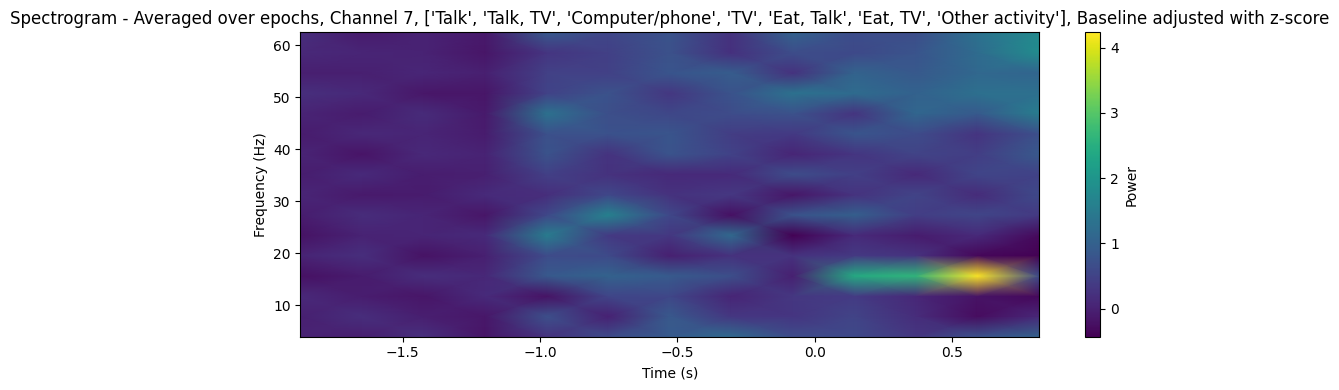

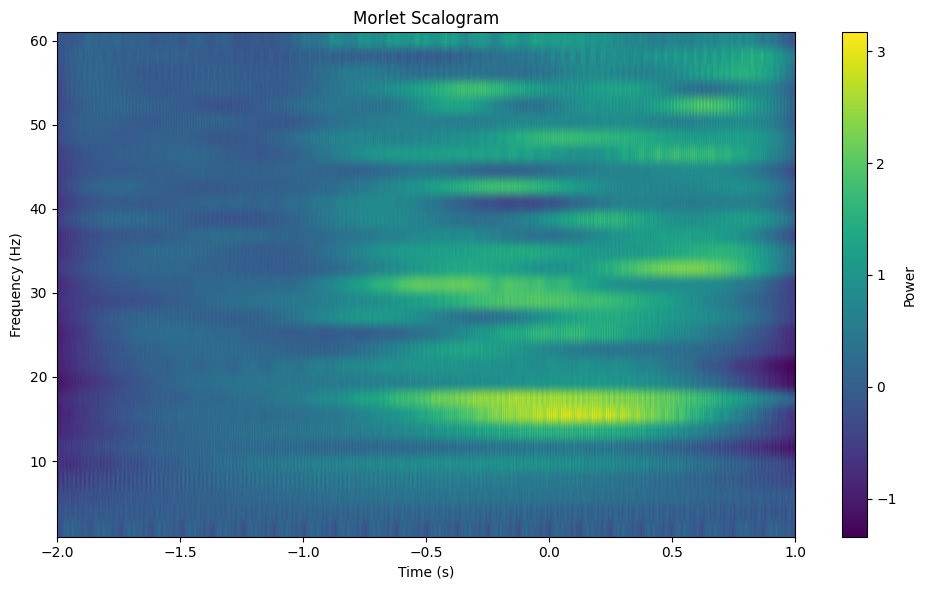

In [40]:
from functions.plotting import plot_spectrogram, plot_morlet


# computes spectrogram for each time epoch around the event, then averages across epochs
# specify parameters
plot_spectrogram(filtered_data, lower_freq=1, upper_freq=65, nperseg=128)

# complex morlet wavelet transform, baseline corrected with z-score (per epoch),
# I will include the option to apply baseline correction after averaging the
# transforms as well.
# specify parameters
plot_morlet(filtered_data, lower_freq=1, upper_freq=60, B=3, C=8)